# Real World Classification

# Load data

In [1]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

seed=40
np.random.seed(seed)

# 3. Data Preprocessing

In [3]:
# Load data from the regularization demo CSV
df = pd.read_csv('data/NYCU_Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,7.0,NaN,4.700000,1.4,16.9,37.5,6.769877,6.755471,6.964281,...,0.466458,0.961982,-0.041964,-2.573335,-0.290155,1.346631,0.334072,0.303819,-1.318415,Iris-versicolor
1,2,6.4,3.2,4.500000,1.5,16.4,95.1,6.202714,6.129652,6.201464,...,-1.270085,1.283433,-1.155498,-0.295384,0.684086,-0.426519,0.113067,1.562539,0.095345,Iris-versicolor
2,3,6.9,NaN,4.900000,1.5,16.9,73.2,6.726317,6.762992,6.784647,...,0.562054,1.238704,0.345857,1.172525,0.320302,-0.563687,-1.514457,-0.179045,-0.577574,Iris-versicolor
3,4,5.5,2.3,5.085612,1.3,15.6,59.9,5.608292,5.529096,5.382254,...,-0.165898,0.914796,1.252364,-0.301381,-0.466333,-0.773040,-0.793858,0.483426,1.210299,Iris-versicolor
4,5,6.5,2.8,4.600000,1.5,16.4,15.6,6.300774,6.443553,6.274360,...,-0.602098,2.045948,-0.465691,0.862299,2.085633,2.047018,0.005283,0.506305,0.766709,Iris-versicolor


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 72 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Id                      500 non-null    int64  
 1   SepalLengthCm           472 non-null    float64
 2   SepalWidthCm            443 non-null    float64
 3   PetalLengthCm           350 non-null    float64
 4   PetalWidthCm            478 non-null    float64
 5   BranchLength            476 non-null    float64
 6   AvgDust                 500 non-null    float64
 7   SepalLengthMajorAxis    500 non-null    float64
 8   SepalLengthMinorAxis    500 non-null    float64
 9   SepalLengthElongation   500 non-null    float64
 10  SepalLengthCompactness  500 non-null    float64
 11  SepalLengthSpread       500 non-null    float64
 12  SepalLengthCurvature    500 non-null    float64
 13  SepalWidthMajorAxis     500 non-null    float64
 14  SepalWidthMinorAxis     500 non-null    fl

In [5]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'BranchLength', 'AvgDust', 'SepalLengthMajorAxis',
       'SepalLengthMinorAxis', 'SepalLengthElongation',
       'SepalLengthCompactness', 'SepalLengthSpread', 'SepalLengthCurvature',
       'SepalWidthMajorAxis', 'SepalWidthMinorAxis', 'SepalWidthElongation',
       'SepalWidthCompactness', 'SepalWidthSpread', 'SepalWidthCurvature',
       'PetalLengthMajorAxis', 'PetalLengthMinorAxis', 'PetalLengthElongation',
       'PetalLengthCompactness', 'PetalLengthSpread', 'PetalLengthCurvature',
       'PetalWidthMajorAxis', 'PetalWidthMinorAxis', 'PetalWidthElongation',
       'PetalWidthCompactness', 'PetalWidthSpread', 'PetalWidthCurvature',
       'IrisPigmentDensity', 'IrisPigmentUniformity', 'IrisPigmentContrast',
       'IrisPigmentGranularity', 'IrisVenationDensity', 'IrisVenationDepth',
       'IrisVenationSharpness', 'IrisVenationAsymmetry', 'FloralSymmetryScore',
       'FloralCompactnessScore', 

In [6]:
df[df['PetalWidthCm']<=0]

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
6,7,6.3,3.3,4.700000,0.0,16.3,5.8,6.217246,6.433263,5.875367,...,0.503332,-0.646084,-1.511858,0.491013,0.317563,-1.104942,1.954232,-2.504990,0.536552,Iris-versicolor
41,42,6.1,3.0,NaN,-0.8,16.3,49.5,6.027123,5.827488,6.159649,...,0.968700,2.183968,-1.641392,-0.491076,-0.446787,-0.605695,-0.704740,-0.241480,0.041670,Iris-versicolor
54,55,6.5,3.0,NaN,-0.8,16.4,59.8,6.557692,6.673522,6.645652,...,0.459890,-1.372103,-1.456807,-0.413252,1.099892,-0.271728,0.028289,0.313557,-0.095100,Iris-virginica
91,92,6.9,3.9,NaN,-0.8,16.7,71.3,6.686094,6.686237,6.945315,...,-0.491275,0.310795,-0.849531,0.338771,0.924154,-0.402139,0.994426,-0.362912,1.128026,Iris-virginica
111,112,6.1,3.3,NaN,-0.0,16.3,5.8,6.228501,6.161557,5.972649,...,0.169808,0.076685,0.314890,0.023609,-0.235674,0.741921,1.040303,0.840125,0.767524,Iris-versicolor
125,126,6.2,3.0,4.600000,-0.9,16.6,49.5,6.479208,5.932342,6.367274,...,0.313866,-0.989002,-0.121396,0.602848,-0.022267,-0.061109,0.564385,-0.647595,0.488089,Iris-versicolor
135,136,6.0,3.2,NaN,-0.6,16.3,49.5,6.103417,5.931254,6.093462,...,0.140324,-0.279034,0.101114,-0.812550,-0.766600,-0.906332,-0.051322,-0.078302,-0.769102,Iris-versicolor
180,181,7.0,3.8,5.100000,-0.9,16.7,71.3,6.886908,6.622694,6.810346,...,-1.484500,0.054368,1.284102,-0.779706,0.388617,-0.849452,0.225983,-0.090232,-0.734670,Iris-virginica
182,183,6.2,3.0,5.085612,-0.8,16.3,49.5,5.786758,6.394371,6.152554,...,-1.649160,-0.415916,0.669971,0.158076,0.156814,-0.592292,-1.135118,2.006897,0.457660,Iris-versicolor
234,235,6.3,3.2,4.700000,-0.0,16.4,5.8,6.435890,6.414014,6.154092,...,0.081866,0.455876,-1.881790,-0.983051,2.850422,1.638473,0.467285,-0.113032,-1.197255,Iris-versicolor


## 3.a. Median and Std report

In [7]:
missing_cols = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'BranchLength']
df[missing_cols].describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength
count,472.000000,443.000000,350.000000,478.000000,476.000000
mean,6.320551,2.837472,5.085612,1.675732,16.302941
std,1.037115,0.389564,1.582807,0.706689,1.035228
min,3.000000,1.500000,0.500000,-1.000000,12.700000
25%,5.800000,2.600000,4.425000,1.300000,15.800000
50%,6.300000,2.900000,5.085612,1.600000,16.300000
75%,6.700000,3.100000,5.500000,2.000000,16.800000
max,9.600000,4.000000,9.200000,4.300000,19.700000


## 3.b. Data Preprocessing - filling missing values

In [8]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

def data_preprocessing(df):
    # transform label to bi-class
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species'])

    feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]

    # transform string to number
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # TODO: Replace the missing values using “Nearest Neighbors Imputation”
    # ---------- Start your code below ----------
    imputer = KNNImputer(n_neighbors=5)
    filled_X = imputer.fit_transform(df[feature_cols])
    df[feature_cols] = filled_X
    # ---------- --------------------- ----------
     
    return df, feature_cols

df, feature_cols = data_preprocessing(df)

In [9]:
print(df.shape, len(feature_cols))

(500, 72) 70


In [10]:
df[missing_cols].describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,6.319840,2.837040,5.049883,1.684440,16.303440
std,1.009275,0.372434,1.514955,0.694645,1.011012
min,3.000000,1.500000,0.500000,-1.000000,12.700000
25%,5.800000,2.630000,4.500000,1.300000,15.800000
50%,6.300000,2.900000,5.035683,1.700000,16.300000
75%,6.700000,3.040000,5.300000,2.000000,16.700000
max,9.600000,4.000000,9.200000,4.300000,19.700000


In [11]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,250.500000,6.319840,2.837040,5.049883,1.684440,16.303440,46.745800,6.316422,6.323365,6.320980,...,0.068882,-0.029672,-0.015074,0.037059,0.082579,0.011686,0.077167,-0.034112,0.029674,0.5200
std,144.481833,1.009275,0.372434,1.514955,0.694645,1.011012,30.032428,1.009859,1.043500,1.024075,...,1.049557,1.046532,1.024190,0.995562,1.033822,1.011917,0.969005,0.949463,0.969047,0.5001
min,1.000000,3.000000,1.500000,0.500000,-1.000000,12.700000,0.600000,2.877573,2.944078,2.955459,...,-3.258345,-3.090824,-2.673773,-2.735569,-3.033392,-2.625754,-3.143116,-2.878216,-2.589544,0.0000
25%,125.750000,5.800000,2.630000,4.500000,1.300000,15.800000,18.500000,5.836615,5.801651,5.793089,...,-0.625022,-0.702388,-0.649046,-0.630572,-0.627218,-0.718793,-0.529432,-0.649448,-0.653394,0.0000
50%,250.500000,6.300000,2.900000,5.035683,1.700000,16.300000,44.000000,6.316422,6.310315,6.320980,...,0.076748,-0.047413,-0.044223,-0.022831,0.109614,-0.017135,0.112847,-0.019524,0.044542,1.0000
75%,375.250000,6.700000,3.040000,5.300000,2.000000,16.700000,73.200000,6.738205,6.797044,6.699885,...,0.806166,0.655584,0.641842,0.750853,0.816614,0.743847,0.751684,0.631034,0.674469,1.0000
max,500.000000,9.600000,4.000000,9.200000,4.300000,19.700000,98.700000,10.032204,10.146460,10.262641,...,3.333114,3.888629,3.174867,3.109433,3.507325,3.100138,2.626066,2.515151,3.254291,1.0000


# 4. Data Exploration

In [12]:
from sklearn.feature_selection import r_regression

# TODO: Complete the 4. Data Exploration

## 4.a. Petal Width histogram

In [13]:
def plot_histogram(data, bins=10, title="Histogram", xlabel="Value", ylabel="Frequency"):
    plt.figure(figsize=(8, 5))
    plt.hist(data, bins=bins, color='skyblue', edgecolor='white', alpha=0.7)

    # Add labels and title
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    # Show grid for better readability
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Display the plot
    plt.show()

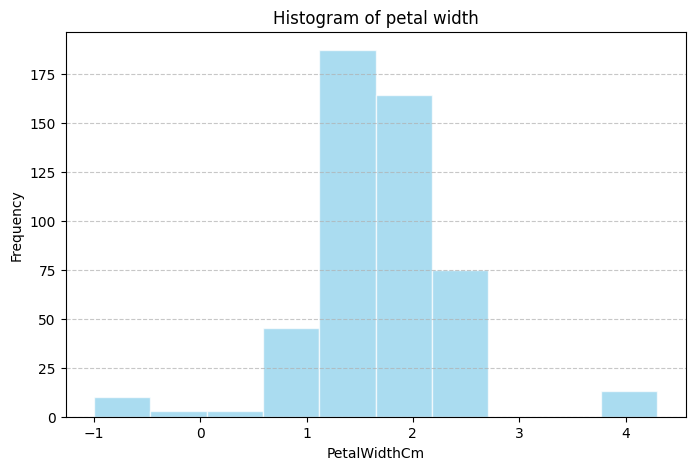

In [14]:
plot_histogram(data=df['PetalWidthCm'], title="Histogram of petal width", xlabel="PetalWidthCm")

## 4.b. The largest positive correlation feature

In [15]:
corr_feature_cols = [col for col in df.columns if col not in ['PetalWidthCm', 'Species', 'Id']]
target_col = 'PetalWidthCm'

corr = r_regression(df[corr_feature_cols], df[target_col])

In [16]:
corr = [(corr_feature_cols [i], corr[i]) for i in range(len(corr))]

In [17]:
largest_pos_corr = sorted(corr, key=lambda x: x[1])[-1]
largest_pos_corr

('PetalWidthCompactness', 0.9916701901370255)

## 4.c. Top 5 features strongest negative correlations

In [18]:
top5_neg_corr = sorted(corr, key=lambda x: x[1])[:5]
top5_neg_corr

[('SepalWidthMajorAxis', -0.09635042983649374),
 ('SepalGlossIndex', -0.09520000072196641),
 ('SepalWidthCompactness', -0.08849639559163781),
 ('SepalWidthCurvature', -0.08133438228330975),
 ('SepalWidthMinorAxis', -0.07439241023821917)]

## 4.d. Plot the boxplot

In [19]:
visualize_cols = [s[0] for s in top5_neg_corr] + [largest_pos_corr[0]]
visualize_cols

['SepalWidthMajorAxis',
 'SepalGlossIndex',
 'SepalWidthCompactness',
 'SepalWidthCurvature',
 'SepalWidthMinorAxis',
 'PetalWidthCompactness']

In [20]:
def plot_box_plot(df, feature_names, yaxis_name = ''):
    data = df[feature_names].to_numpy().T.tolist()
    labels = feature_names
    
    plt.figure(figsize=(4, 5))
    bp = plt.boxplot(data, patch_artist=True, labels=labels)
    
    cmap = plt.get_cmap('viridis')
    colors = [cmap(i) for i in np.linspace(0, 1, len(data))]
    
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    plt.xticks(rotation=45, fontsize=8)
    
    plt.yticks(fontsize=8)
    
    # plt.title('Box Plot', fontsize=8)
    plt.tight_layout()
    plt.show()

/var/folders/z8/83f0z7r55bldb3vm13m0_6jr0000gn/T/ipykernel_6588/2194051922.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data, patch_artist=True, labels=labels)


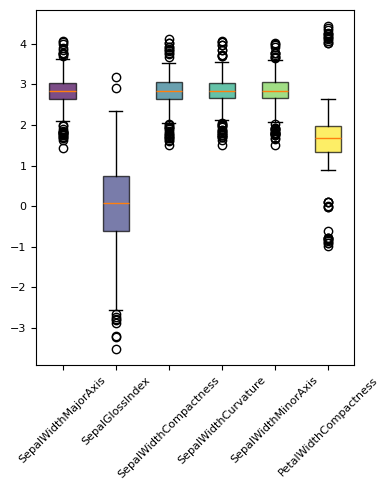

In [21]:
plot_box_plot(df, feature_names=visualize_cols, yaxis_name = '')

# 5. Model Training

## Prepare the data

In [22]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

# normalize the data to [0,1]
for col in feature_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_max > col_min:
        df[col] = (df[col] - col_min) / (col_max - col_min)
    else:
        df[col] = 0.0
        
X = df[feature_cols].values.astype(float)
y = df['Species'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,0.606061,0.608,0.482759,0.452830,0.600000,0.376147,0.544026,0.529185,0.548614,...,0.565095,0.580677,0.449986,0.027756,0.419409,0.693758,0.602718,0.589990,0.217516,0
1,2,0.515152,0.680,0.459770,0.471698,0.528571,0.963303,0.464754,0.442295,0.444221,...,0.301642,0.626733,0.259595,0.417482,0.568359,0.384086,0.564410,0.823373,0.459439,0
2,3,0.590909,0.616,0.505747,0.471698,0.600000,0.740061,0.537937,0.530229,0.524031,...,0.579598,0.620325,0.516296,0.668622,0.512741,0.360130,0.282303,0.500461,0.344289,0
3,4,0.378788,0.320,0.527082,0.433962,0.414286,0.604485,0.381672,0.358911,0.332111,...,0.469160,0.573916,0.671291,0.416456,0.392474,0.323568,0.407208,0.623292,0.650231,0
4,5,0.530303,0.520,0.471264,0.471698,0.528571,0.152905,0.478459,0.485877,0.454197,...,0.402983,0.735985,0.377538,0.615546,0.782640,0.816078,0.545727,0.627534,0.574324,0


## Train the model!

In [23]:
# Use the LinearModel to fit the data
from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid
from model.metrics import evaluate_binary_classifier

# Model configuration
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

np.random.seed(seed)

### Train model without regularization

50. Training loss: 0.6183886535310102, Val loss:0.6383381911771239
100. Training loss: 0.5960033921480784, Val loss:0.6229857283892484
150. Training loss: 0.5781690886526527, Val loss:0.6111796844177572
200. Training loss: 0.5636439627476497, Val loss:0.601978582536059
250. Training loss: 0.5515861130769195, Val loss:0.5947349187857766
300. Training loss: 0.5414115554176107, Val loss:0.588991764914238
350. Training loss: 0.5327055446405081, Val loss:0.5844187428740432
400. Training loss: 0.5251667000245236, Val loss:0.5807716266567299
450. Training loss: 0.5185712433977272, Val loss:0.5778662753932695
500. Training loss: 0.5127496761323889, Val loss:0.5755614147648994
550. Training loss: 0.5075712624849853, Val loss:0.5737469965121451
600. Training loss: 0.5029334978289508, Val loss:0.5723361523089564
650. Training loss: 0.49875481918863035, Val loss:0.571259514930716
700. Training loss: 0.4949694641429734, Val loss:0.5704611319860386
750. Training loss: 0.4915237794843891, Val loss:0.

8700. Training loss: 0.4240584830425822, Val loss:0.6389606121918174
8750. Training loss: 0.4239855018079032, Val loss:0.6392356227279589
8800. Training loss: 0.4239130275593235, Val loss:0.6395091180374245
8850. Training loss: 0.4238410516441586, Val loss:0.6397811095583208
8900. Training loss: 0.4237695656045037, Val loss:0.6400516085942519
8950. Training loss: 0.42369856117195975, Val loss:0.6403206263167867
9000. Training loss: 0.4236280302625266, Val loss:0.6405881737678668
9050. Training loss: 0.4235579649716569, Val loss:0.6408542618621637
9100. Training loss: 0.4234883575694643, Val loss:0.6411189013893839
9150. Training loss: 0.42341920049608195, Val loss:0.6413821030165243
9200. Training loss: 0.4233504863571644, Val loss:0.6416438772900764
9250. Training loss: 0.42328220791952753, Val loss:0.6419042346381848
9300. Training loss: 0.4232143581069241, Val loss:0.642163185372756
9350. Training loss: 0.42314692999594794, Val loss:0.6424207396915227
9400. Training loss: 0.42307991

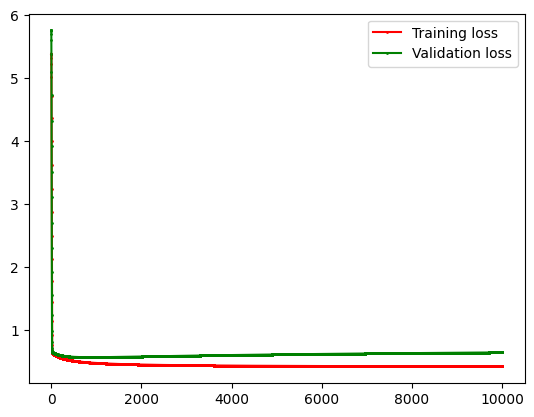

Model parameters (weights): [[-3.09226542]
 [ 0.81422629]
 [ 0.35178624]
 [-0.7609665 ]
 [ 0.86152155]
 [-0.01533802]
 [ 0.29669952]
 [-0.03629679]
 [ 0.20223017]
 [ 1.8869661 ]
 [ 0.87767537]
 [ 0.74544323]
 [ 1.16299519]
 [ 0.19552937]
 [-1.00811454]
 [-0.10050799]
 [ 1.60616526]
 [ 0.70302677]
 [ 0.15269826]
 [ 0.18948831]
 [ 0.26495978]
 [ 0.49098399]
 [-0.11040372]
 [ 0.66380585]
 [ 0.43424603]
 [ 2.06351944]
 [ 1.76565182]
 [ 1.74553348]
 [ 2.00502818]
 [ 1.80907373]
 [ 1.7727681 ]
 [-2.27530402]
 [ 1.42115829]
 [-0.39117344]
 [ 0.27016079]
 [-1.48784374]
 [ 0.60407509]
 [-1.09556673]
 [-3.03287109]
 [-0.45021112]
 [-1.22819914]
 [-0.42913274]
 [-0.96548124]
 [-1.23728785]
 [ 0.52211853]
 [-0.03098011]
 [ 0.01005535]
 [ 0.29405703]
 [-0.60621754]
 [-0.66869117]
 [-0.47178247]
 [ 0.33885952]
 [ 0.17406024]
 [-0.59406833]
 [-0.3958753 ]
 [ 0.48301625]
 [-0.85626669]
 [-1.22172831]
 [-0.30024527]
 [ 0.56252418]
 [-1.00901787]
 [ 0.747168  ]
 [ 0.62641196]
 [-1.6014551 ]
 [ 0.1372598

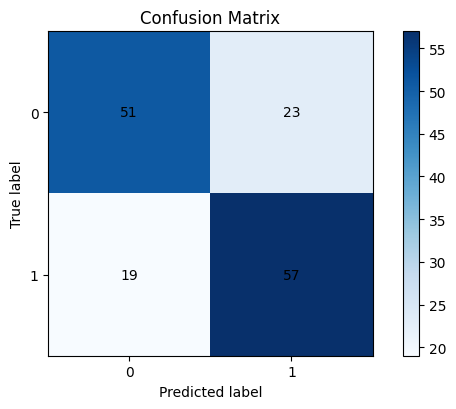

{'Accuracy': 0.72,
 'Precision': 0.7125,
 'Recall': 0.75,
 'F1-score': 0.7307692307692307}

In [24]:
seed=40
np.random.seed(seed)

model = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
model.fit(X_train, y_train,lr=0.1, n_iteration =10000,val_ratio=0.2, reg_type='', reg_lambda=0.0)

# print model parameters
print("Model parameters (weights):", model.W)
# sum of absolute values of weights
print("Sum of absolute values of weights:", np.sum(np.abs(model.W)))

y_pred = model.predict(X_test)
evaluate_binary_classifier(y_test, y_pred)

### Train models with L2 regularization


================ reg_lambda = 0.01 ================
50. Training loss: 0.6183968442308057, Val loss:0.6383418749174559
100. Training loss: 0.5960218584459506, Val loss:0.6229937284988916
150. Training loss: 0.5781987940557217, Val loss:0.6111917862872271
200. Training loss: 0.5636852669117252, Val loss:0.6019940821319419
250. Training loss: 0.5516390786456719, Val loss:0.5947528491389577
300. Training loss: 0.5414760921827048, Val loss:0.5890110215795246
350. Training loss: 0.5327814781753895, Val loss:0.5844381571451082
400. Training loss: 0.5252538055110114, Val loss:0.5807900103412458
450. Training loss: 0.5186692635109195, Val loss:0.5778824491950174
500. Training loss: 0.5128583316269498, Val loss:0.5755742266452543
550. Training loss: 0.5076902593666242, Val loss:0.57375533358103
600. Training loss: 0.5030625328026356, Val loss:0.5723389483402412
650. Training loss: 0.4988935840888995, Val loss:0.5712557548145529
700. Training loss: 0.4951176496280415, Val loss:0.570449853988832

6100. Training loss: 0.42937450276635564, Val loss:0.6199043187447254
6150. Training loss: 0.4292575185032829, Val loss:0.6202525951715449
6200. Training loss: 0.4291419842701384, Val loss:0.6205984636045795
6250. Training loss: 0.42902786637095786, Val loss:0.6209419485121278
6300. Training loss: 0.42891513212351595, Val loss:0.621283073978516
6350. Training loss: 0.4288037498221879, Val loss:0.6216218637116783
6400. Training loss: 0.4286936887024302, Val loss:0.6219583410506058
6450. Training loss: 0.42858491890679856, Val loss:0.6222925289726647
6500. Training loss: 0.42847741145242335, Val loss:0.6226244501007856
6550. Training loss: 0.42837113819987127, Val loss:0.6229541267105135
6600. Training loss: 0.42826607182332455, Val loss:0.623281580736933
6650. Training loss: 0.4281621857820095, Val loss:0.6236068337814549
6700. Training loss: 0.42805945429281694, Val loss:0.6239299071184745
6750. Training loss: 0.42795785230405536, Val loss:0.6242508217018968
6800. Training loss: 0.4278

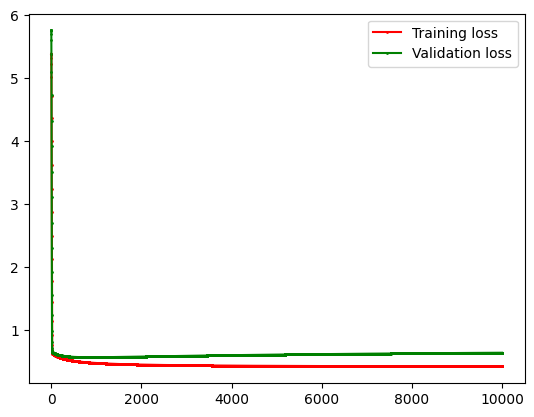

Model parameters (weights): [[-2.97876505]
 [ 0.81130731]
 [ 0.35528897]
 [-0.73679613]
 [ 0.87659738]
 [ 0.00714037]
 [ 0.29226848]
 [-0.01772541]
 [ 0.20894927]
 [ 1.82921786]
 [ 0.85907033]
 [ 0.72379246]
 [ 1.13860011]
 [ 0.18023064]
 [-0.98074977]
 [-0.08251054]
 [ 1.54000897]
 [ 0.68242964]
 [ 0.1607335 ]
 [ 0.17939641]
 [ 0.27374655]
 [ 0.49310344]
 [-0.09550356]
 [ 0.64472868]
 [ 0.41315937]
 [ 2.01483644]
 [ 1.73912209]
 [ 1.7167826 ]
 [ 1.96135615]
 [ 1.78457872]
 [ 1.74015759]
 [-2.2200224 ]
 [ 1.38375193]
 [-0.38485774]
 [ 0.2569879 ]
 [-1.44347253]
 [ 0.58870085]
 [-1.07510967]
 [-2.96865714]
 [-0.4420989 ]
 [-1.20536784]
 [-0.42415863]
 [-0.95640275]
 [-1.21105373]
 [ 0.50705798]
 [-0.04846362]
 [ 0.00309922]
 [ 0.27501913]
 [-0.59831019]
 [-0.66043573]
 [-0.46393957]
 [ 0.3174146 ]
 [ 0.16453656]
 [-0.58687953]
 [-0.38301178]
 [ 0.46861583]
 [-0.84259829]
 [-1.20525122]
 [-0.2997417 ]
 [ 0.53205457]
 [-0.99486234]
 [ 0.72265591]
 [ 0.60878032]
 [-1.57244871]
 [ 0.1224894

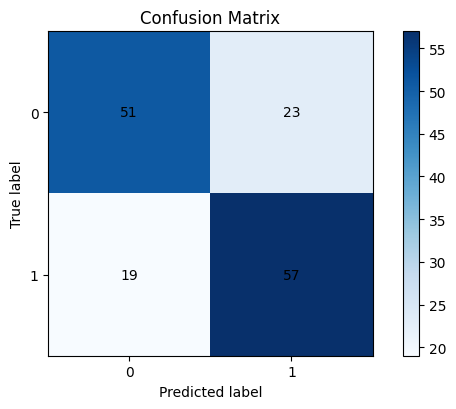


================ reg_lambda = 1 ================
50. Training loss: 0.6192229675550639, Val loss:0.6387339171797572
100. Training loss: 0.5979091328910923, Val loss:0.6238920902494233
150. Training loss: 0.5812650420168968, Val loss:0.6126225576568589
200. Training loss: 0.5679827993268195, Val loss:0.6039318894908267
250. Training loss: 0.5571858255876309, Val loss:0.5971444430979668
300. Training loss: 0.5482708567526591, Val loss:0.59178857989705
350. Training loss: 0.5408117331839131, Val loss:0.5875271116871132
400. Training loss: 0.5344999386168847, Val loss:0.5841138047798572
450. Training loss: 0.5291070807888374, Val loss:0.5813654836364933
500. Training loss: 0.524460662779445, Val loss:0.5791436781671647
550. Training loss: 0.5204280628046019, Val loss:0.577342251554659
600. Training loss: 0.5169056942810415, Val loss:0.5758788683267105
650. Training loss: 0.5138115085968704, Val loss:0.57468898760961
700. Training loss: 0.511079702784841, Val loss:0.5737215545999529
750. T

6300. Training loss: 0.48381072446573165, Val loss:0.5719387529801423
6350. Training loss: 0.48380899591980253, Val loss:0.5719397597275517
6400. Training loss: 0.483807350673243, Val loss:0.5719407198926649
6450. Training loss: 0.48380578456158624, Val loss:0.571941635706226
6500. Training loss: 0.4838042936371368, Val loss:0.5719425092881761
6550. Training loss: 0.48380287415716194, Val loss:0.5719433426533362
6600. Training loss: 0.4838015225727592, Val loss:0.5719441377167891
6650. Training loss: 0.48380023551836127, Val loss:0.5719448962989843
6700. Training loss: 0.4837990098018401, Val loss:0.5719456201305746
6750. Training loss: 0.4837978423951711, Val loss:0.5719463108570011
6800. Training loss: 0.48379673042562704, Val loss:0.5719469700428368
6850. Training loss: 0.483795671167467, Val loss:0.5719475991759069
6900. Training loss: 0.48379466203409344, Val loss:0.5719481996711904
6950. Training loss: 0.4837937005706469, Val loss:0.5719487728745203
7000. Training loss: 0.4837927

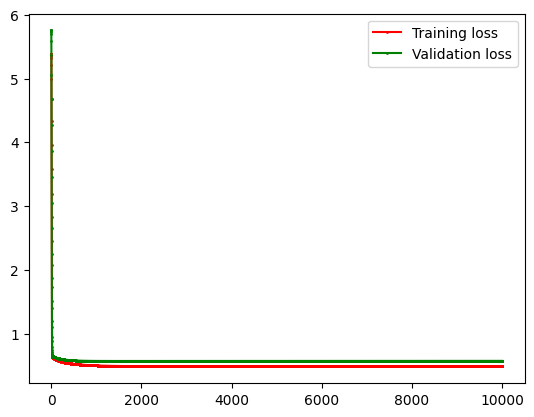

Model parameters (weights): [[-0.6736172 ]
 [ 0.48849652]
 [ 0.179458  ]
 [-0.01432622]
 [ 0.80333745]
 [ 0.31657614]
 [ 0.20007635]
 [ 0.28825311]
 [ 0.32984404]
 [ 0.52401411]
 [ 0.40304197]
 [ 0.37827534]
 [ 0.47899858]
 [ 0.02790797]
 [-0.14438477]
 [ 0.10533422]
 [ 0.24353204]
 [ 0.19134209]
 [ 0.13862588]
 [ 0.13162341]
 [ 0.22633432]
 [ 0.27839164]
 [ 0.15181066]
 [ 0.24553839]
 [ 0.16545861]
 [ 0.8529222 ]
 [ 0.86820804]
 [ 0.87376073]
 [ 0.88927071]
 [ 0.91004762]
 [ 0.87391149]
 [-0.71611561]
 [ 0.33682521]
 [-0.22246403]
 [-0.00507796]
 [-0.36644352]
 [ 0.08087238]
 [-0.45789113]
 [-1.16842485]
 [-0.1859957 ]
 [-0.50217185]
 [-0.21872532]
 [-0.56235885]
 [-0.43939383]
 [ 0.10080915]
 [-0.24072012]
 [-0.17200155]
 [-0.13675272]
 [-0.34467403]
 [-0.35870215]
 [-0.21152253]
 [-0.11000756]
 [-0.08478125]
 [-0.30106099]
 [-0.12437904]
 [ 0.05426102]
 [-0.41635178]
 [-0.58111666]
 [-0.24637554]
 [-0.08877881]
 [-0.55101013]
 [ 0.10701598]
 [ 0.17933916]
 [-0.6301576 ]
 [-0.1842469

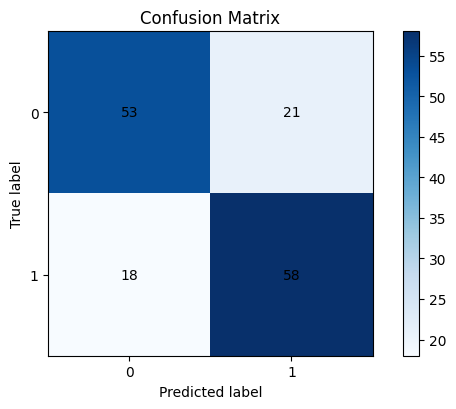


================ reg_lambda = 100 ================
50. Training loss: 0.6737565170340649, Val loss:0.6828695995569816
100. Training loss: 0.6747289430162428, Val loss:0.6839071965242837
150. Training loss: 0.6747483271618208, Val loss:0.6839293732638189
200. Training loss: 0.6747487102403308, Val loss:0.6839298451300981
250. Training loss: 0.674748717829201, Val loss:0.6839298552460086
300. Training loss: 0.6747487179798805, Val loss:0.6839298554645057
350. Training loss: 0.6747487179828774, Val loss:0.6839298554692588
400. Training loss: 0.674748717982937, Val loss:0.6839298554693629
450. Training loss: 0.6747487179829381, Val loss:0.683929855469365
500. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
550. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
600. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
650. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
700. Training loss: 0.6747487179829382, Val loss:0.6839298554693651


7100. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
7150. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
7200. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
7250. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
7300. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
7350. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
7400. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
7450. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
7500. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
7550. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
7600. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
7650. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
7700. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
7750. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
7800. Training loss: 0.67474871798

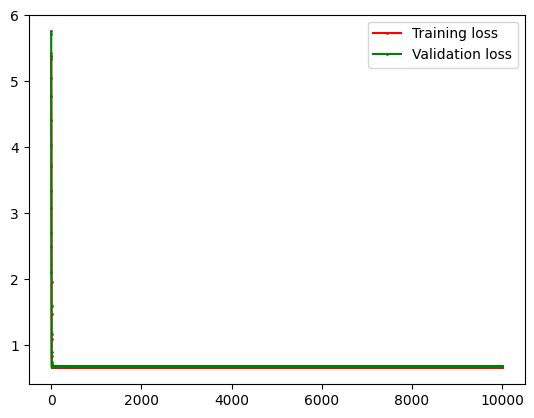

Model parameters (weights): [[-0.01249206]
 [ 0.02228109]
 [ 0.00731174]
 [ 0.02160094]
 [ 0.03647292]
 [ 0.01868654]
 [ 0.01769178]
 [ 0.01789019]
 [ 0.01923883]
 [ 0.02027882]
 [ 0.01914643]
 [ 0.02013799]
 [ 0.02095232]
 [ 0.00458568]
 [ 0.00311998]
 [ 0.00605684]
 [ 0.00705284]
 [ 0.00742952]
 [ 0.00627274]
 [ 0.02328098]
 [ 0.02385686]
 [ 0.02565637]
 [ 0.02391417]
 [ 0.02520387]
 [ 0.02375411]
 [ 0.03462815]
 [ 0.03522777]
 [ 0.03662822]
 [ 0.03649798]
 [ 0.036714  ]
 [ 0.03671077]
 [-0.01304758]
 [ 0.00456383]
 [-0.00644573]
 [-0.00238571]
 [-0.00519696]
 [-0.00335385]
 [-0.0124363 ]
 [-0.02754184]
 [-0.00523545]
 [-0.00983527]
 [-0.0041134 ]
 [-0.01539004]
 [-0.00700335]
 [-0.0017571 ]
 [-0.00552268]
 [-0.00863107]
 [-0.00523874]
 [-0.01145154]
 [-0.00881981]
 [-0.00133932]
 [-0.00757033]
 [-0.00632656]
 [-0.0080036 ]
 [-0.00210421]
 [-0.00160616]
 [-0.00839356]
 [-0.01317914]
 [-0.00861225]
 [-0.01061584]
 [-0.01525315]
 [-0.00042755]
 [ 0.00442472]
 [-0.01255564]
 [-0.0094437

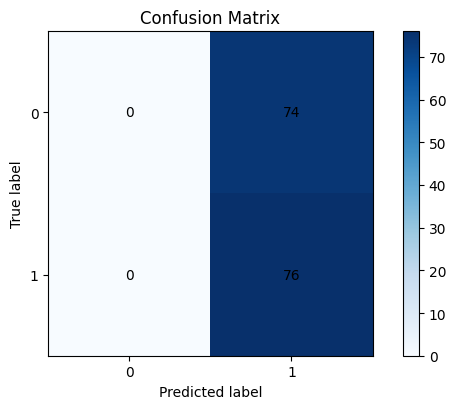

In [25]:
regs = [0.01, 1, 100]

for reg in regs:
    seed=40
    np.random.seed(seed)

    print(f'\n================ reg_lambda = {reg} ================')
    model = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
    model.fit(X_train, y_train,lr=0.1, n_iteration =10000,val_ratio=0.2, reg_type='l2', reg_lambda=reg)
    # print model parameters
    print("Model parameters (weights):", model.W)
    # sum of absolute values of weights
    print("Sum of absolute values of weights:", np.sum(np.abs(model.W)))

    y_pred = model.predict(X_test)
    evaluate_binary_classifier(y_test, y_pred)